data loading and converting it to csv file

In [1]:
import sys
import os
%load_ext autoreload
%autoreload 2
# Tell the notebook where to find your 'src' folder
sys.path.append(os.path.abspath('../'))
from src.data_loader import  load_data
from src.eda_utils import cast_columns, pre_eda_profile, handle_missing_values
from src.visualizations import (
    prepare_plotting_data,
    plot_univariate_distributions,
    plot_premium_vs_claims,
    plot_province_risk,
    plot_outliers,
    plot_loss_ratio,
    plot_temporal_trends,
    plot_vehicle_claims
)


In [2]:
#load file to pd dataframe
raw_df = load_data()


c:\Users\Hermela\Desktop\10academy\week3\src\data_loader.py:10: DtypeWarning: Columns (0: Citizenship, 1: CapitalOutstanding, 2: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Data Summarization

In [3]:
raw_df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [4]:
# Cast columns to correct dtypes before profiling.
df = cast_columns(raw_df)


In [5]:
#analyze the cleaned structure
missing_report = pre_eda_profile(df)


1. DTYPE SUMMARY

  NUMERIC (FLOAT64) (10)
    • cubiccapacity
    • kilowatts
    • CustomValueEstimate
    • CapitalOutstanding
    • NumberOfVehiclesInFleet
    • SumInsured
    • CalculatedPremiumPerTerm
    • ExcessSelected
    • TotalPremium
    • TotalClaims

  NUMERIC (NULLABLE INT) (3)
    • RegistrationYear
    • Cylinders
    • NumberOfDoors

  BOOLEAN (NULLABLE) (7)
    • IsVATRegistered
    • AlarmImmobiliser
    • TrackingDevice
    • WrittenOff
    • Rebuilt
    • Converted
    • CrossBorder

  CATEGORICAL (26)
    • Citizenship
    • LegalType
    • Title
    • Language
    • Bank
    • AccountType
    • MaritalStatus
    • Gender
    • Country
    • Province
    • MainCrestaZone
    • SubCrestaZone
    • ItemType
    • VehicleType
    • make
    • Model
    • bodytype
    • NewVehicle
    • TermFrequency
    • CoverCategory
    • CoverType
    • CoverGroup
    • Section
    • Product
    • StatutoryClass
    • StatutoryRiskType

  STRING (4)
    • UnderwrittenCoverID
 

 Data Quality Assessment 

In [6]:
missing_report.sort_values("pct", ascending=False).head(15)

,missing,pct
NumberOfVehiclesInFleet,1000098,100.00
ExcessSelected,1000098,100.00
CrossBorder,999400,99.93
Citizenship,895210,89.51
CustomValueEstimate,779642,77.96
Converted,641901,64.18
WrittenOff,641901,64.18
Rebuilt,641901,64.18
NewVehicle,153295,15.33
Bank,145961,14.59


Handle missing values using scalable and business-aware preprocessing strategies for insurance datasets.

In [7]:
clean_df = handle_missing_values(df)

MISSING VALUE HANDLING

1. DROPPING EXTREMELY MISSING COLUMNS
  • Citizenship (89.51% missing)
  • CrossBorder (99.93% missing)
  • NumberOfVehiclesInFleet (100.0% missing)
  • ExcessSelected (100.0% missing)

2. MEDIAN IMPUTATION — CONTINUOUS FEATURES
  • cubiccapacity: filled 552 missing values with median = 2694.0
  • kilowatts: filled 552 missing values with median = 111.0
  • CapitalOutstanding: filled 322 missing values with median = 0.0

3. MODE IMPUTATION — DISCRETE FEATURES
  • Cylinders: filled 552 missing values with mode = 4
  • NumberOfDoors: filled 552 missing values with mode = 4

3.5. INFERRING GENDER FROM TITLE
  • Gender: Deterministically inferred 867,031 human values from Title.
  • Gender: Left Corporate/Commercial entities as Unknown/NaN.

4. CATEGORICAL IMPUTATION (FALLBACK)
  • Bank: filled 145,961 missing values with 'Unknown'
  • AccountType: filled 40,232 missing values with 'Unknown'
  • Gender: filled 83,495 missing values with 'Unknown'
  • MaritalStatus: 

In [8]:
clean_df.shape

(999546, 48)

In [9]:
# 1. Run the preprocessing step to generate the necessary dataframes
df_clean, df_plot, zip_summary = prepare_plotting_data(clean_df)


Preparing data for visualizations...
✅ Preprocessing complete. Dataframes ready for plotting.


c:\Users\Hermela\Desktop\10academy\week3\src\visualizations.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='VehicleType', data=df, order=top_vehicles, palette='Blues_r', ax=axes[1, 0])
c:\Users\Hermela\Desktop\10academy\week3\src\visualizations.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='CoverType', data=df, order=top_covers, palette='Oranges_r', ax=axes[1, 1])


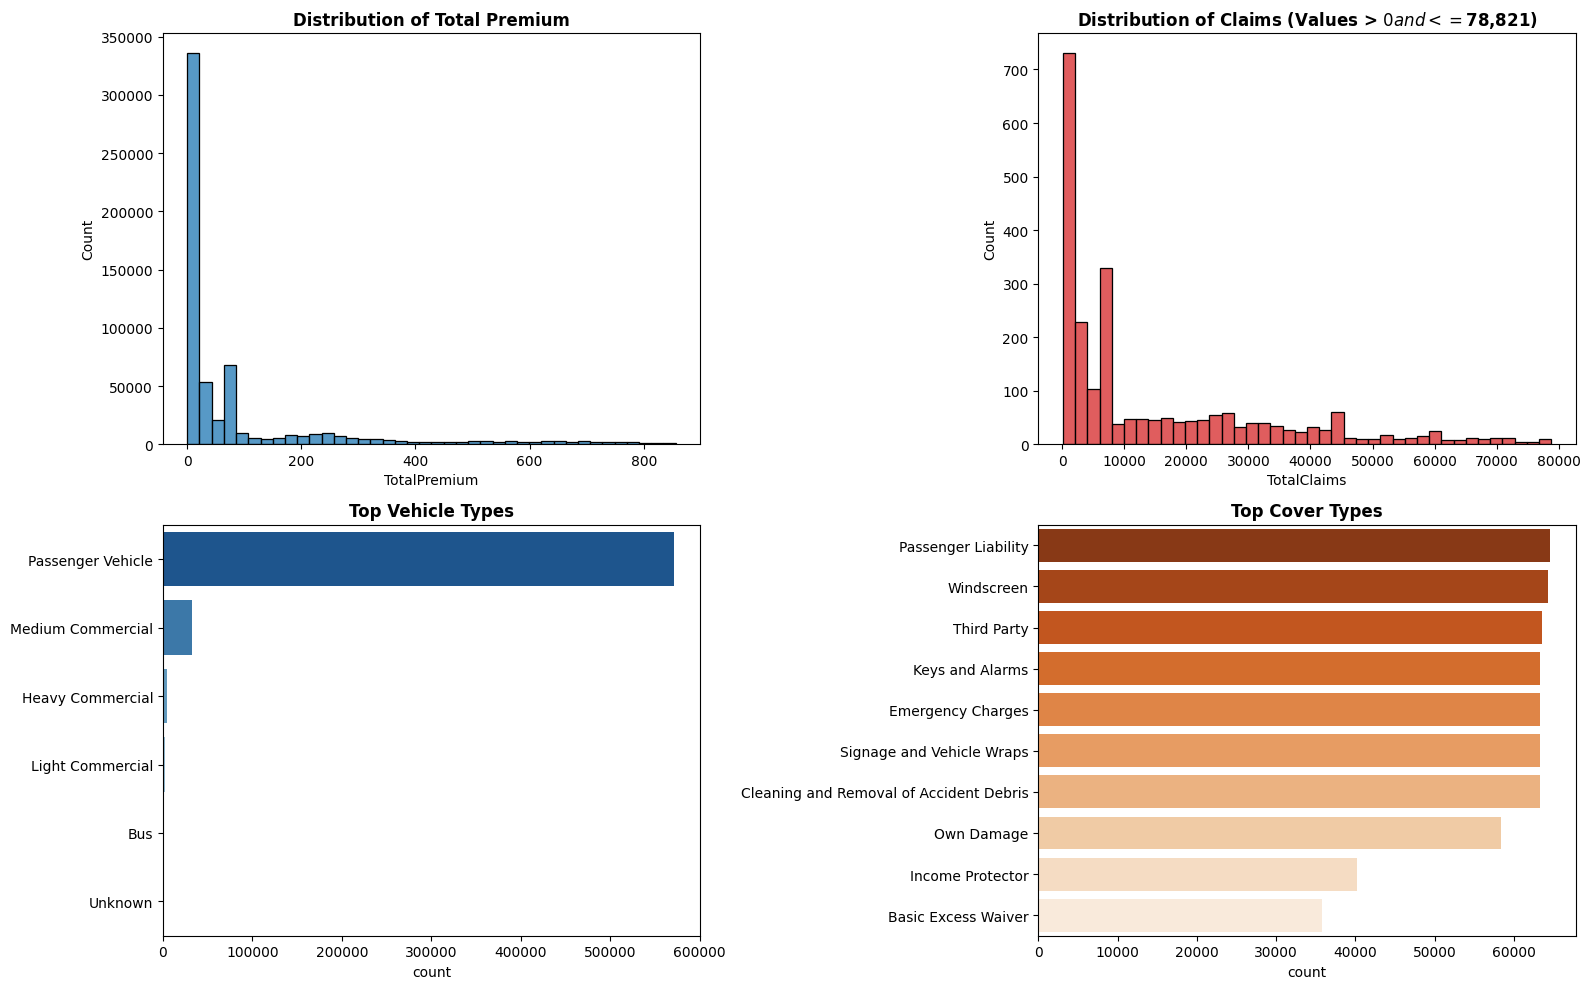

In [10]:
# 2. Univariate Analysis -
plot_univariate_distributions(df_plot)


We are fundamentally a passenger vehicle insurer. Passenger Vehicles completely dwarf all commercial types combined. Financially, our data is heavily right-skewed; the vast majority of our policies generate low base premiums, while claim payouts cluster near the lower end but carry a long, expensive tail up to $80,000. Additionally, consumers strongly prefer specific protections, with Passenger Liability and Windscreen coverage ranking at the very top.

Business Recommendation: Because consumer passenger vehicles fund our entire business model and absorb the impact of extreme outlier claims, we must aggressively prioritize retaining these drivers with highly competitive base rates. Furthermore, since the data proves consumers already overwhelmingly select Passenger Liability and Windscreen coverage, marketing should immediately bundle these together into a "Standard Protection" tier to drive upsells.

Bivariate / Multivariate Analysis 

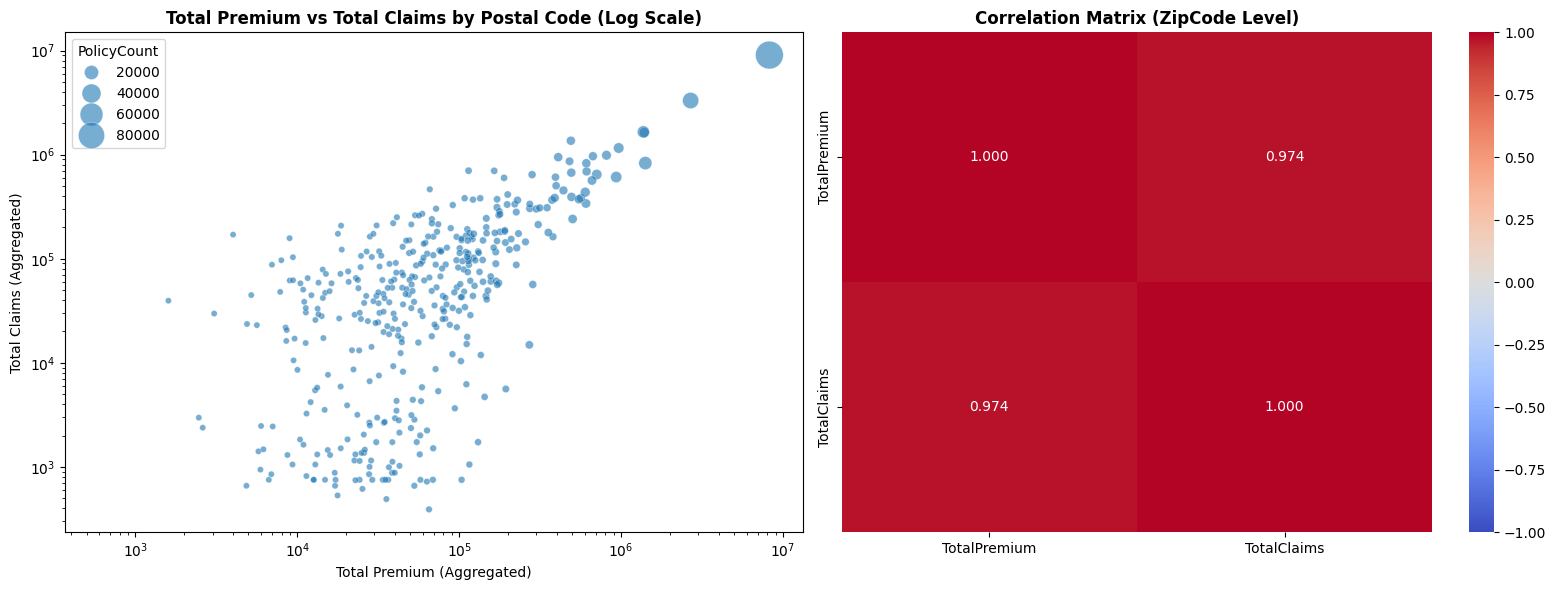

In [11]:
plot_premium_vs_claims(zip_summary)


Total premiums and total claims move in near-perfect lockstep. The correlation matrix reveals a massive 0.974 positive correlation between the two. The log-scale scatter plot confirms a tight, predictable linear relationship, with our highest-volume postal codes (the largest bubbles) anchoring the center of the trend.

Business Recommendation: Our macro-level pricing structure works exactly as intended; as regional claim severity increases, our collected premiums scale proportionally. Moving forward, the pricing team must isolate and investigate the specific postal codes (bubbles) that float above the main diagonal trend line. These specific zip codes represent localized areas where claim payouts are outpacing premium collection.

Geographic Trends 

c:\Users\Hermela\Desktop\10academy\week3\src\visualizations.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalPremium', y='Province', data=prov_prem, palette='Blues_r', ax=axes[0])


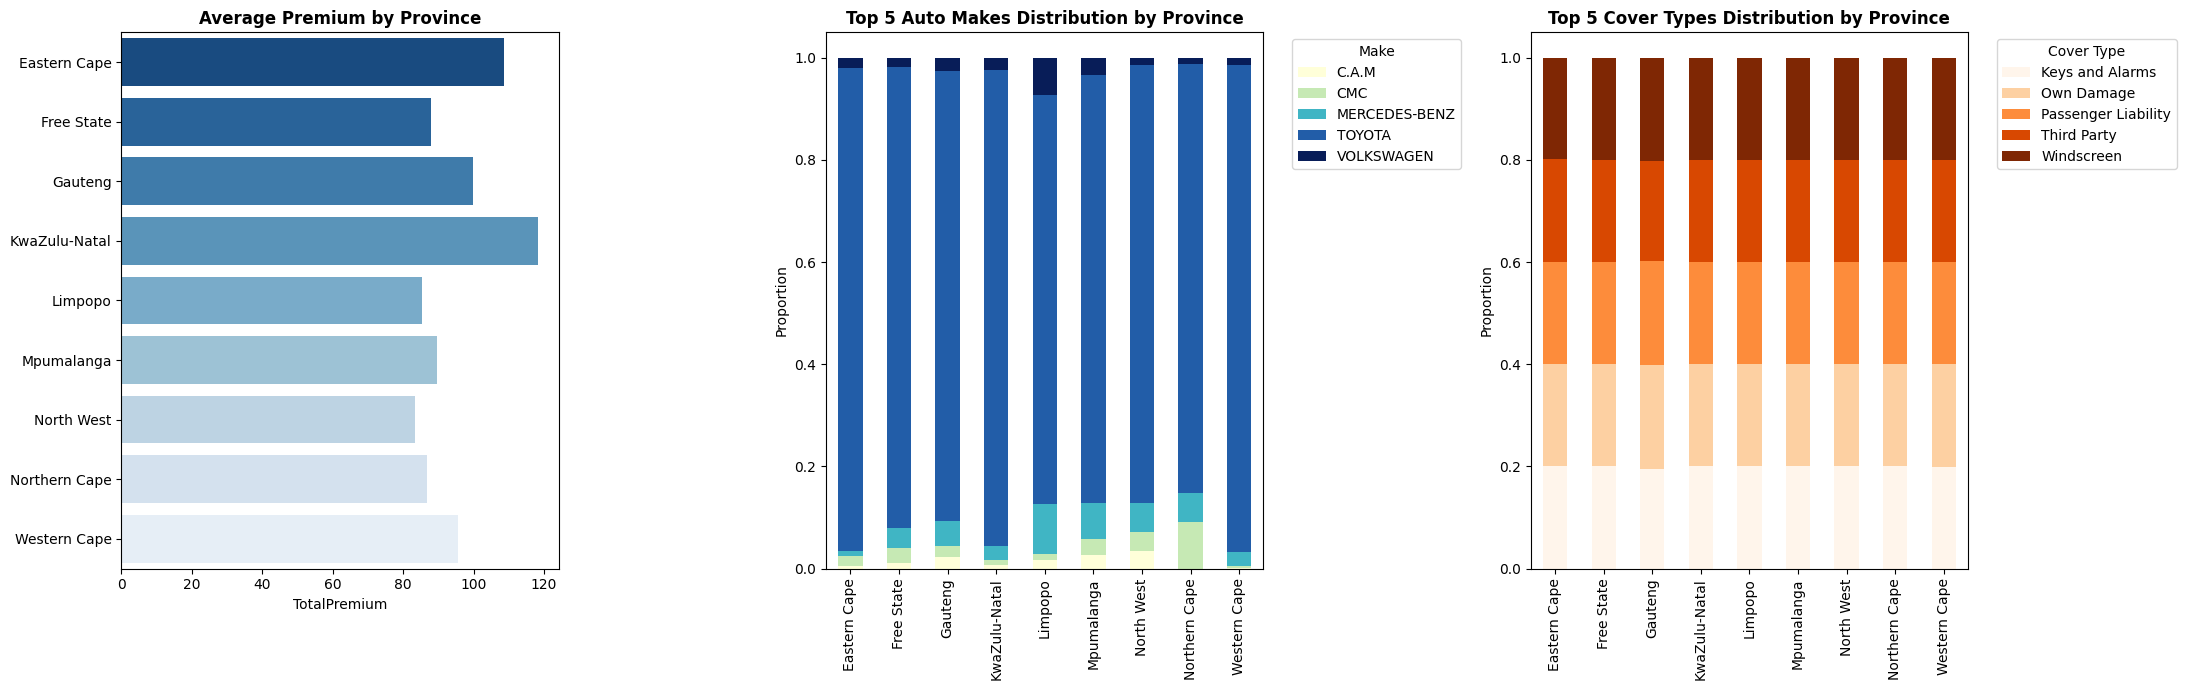

In [12]:
plot_province_risk(df_clean)


KwaZulu-Natal generates the highest average premiums, followed closely by the Eastern Cape and Gauteng. Interestingly, despite differences in premium pricing, our portfolio mix shows zero regional variation. Toyota holds a complete monopoly across every single province. Furthermore, policyholders select cover types (like Own Damage, Third Party, and Windscreen) in perfectly equal proportions regardless of where they live.

Business Recommendation: Because our vehicle mix and coverage selections are completely uniform across the country, regional pricing differences must stem entirely from local environmental risks (like localized accident rates, traffic density, or theft). We should confidently price our regional premiums based purely on local geographic claim frequencies, without worrying about adjusting for vehicle brand mix.

Outlier Detection

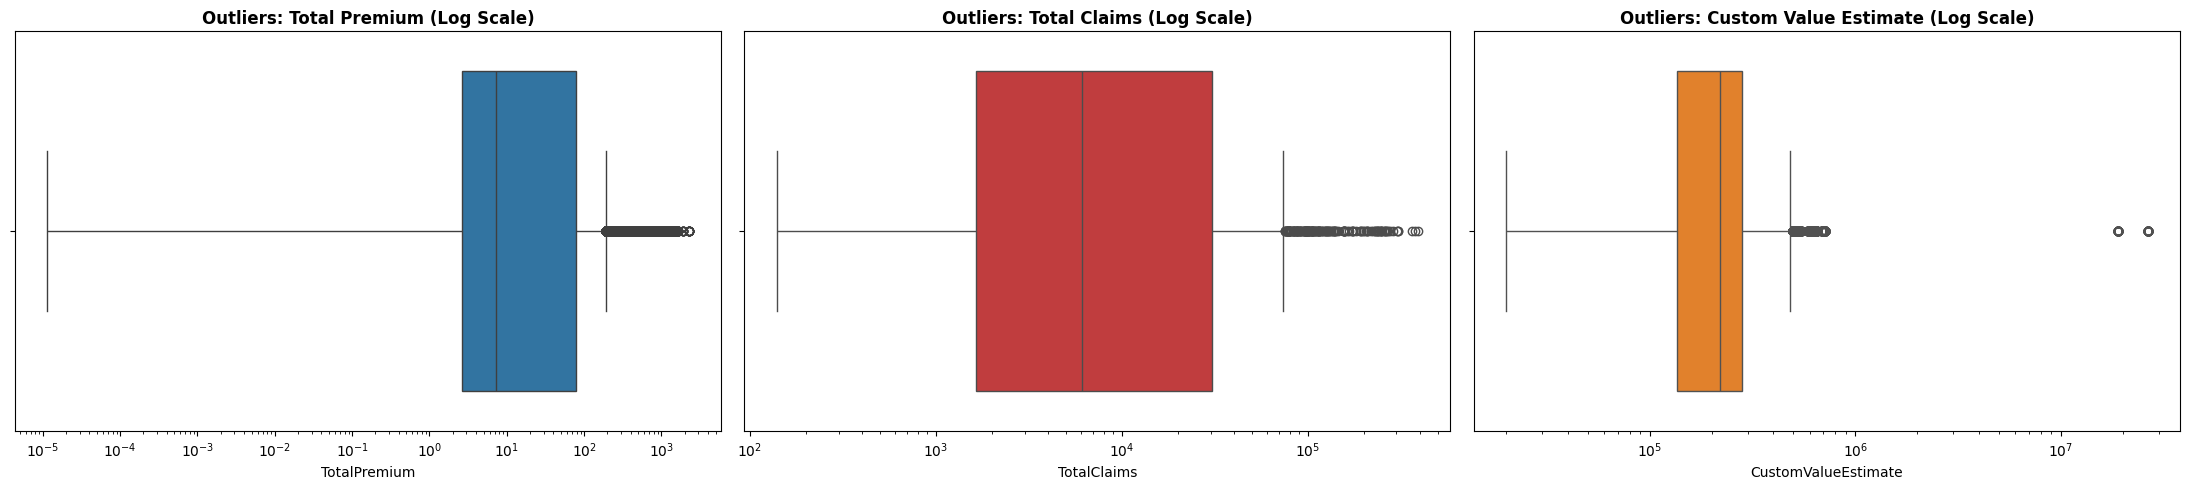

In [13]:
plot_outliers(df_clean)

The portfolio relies heavily on high-volume, low-premium policies, but it is exposed to massive, right-skewed financial outliers. The log-scale box plots reveal a long tail of extreme claims stretching heavily to the right. Furthermore, the CustomValueEstimate shows that the portfolio is mixing standard consumer vehicles with exceptionally high-value assets.

Strategy: This is the fundamental nature of the insurance business model—thousands of safe policies fund the catastrophic losses of a few. I chose not to remove these outliers, as severe claims are a natural part of insurance risk. However, moving forward, the business should implement strict underwriting caps based on the CustomValueEstimate. For vehicles exceeding a specific valuation threshold (e.g., the 95th percentile), we must secure reinsurance to protect the company's balance sheet.

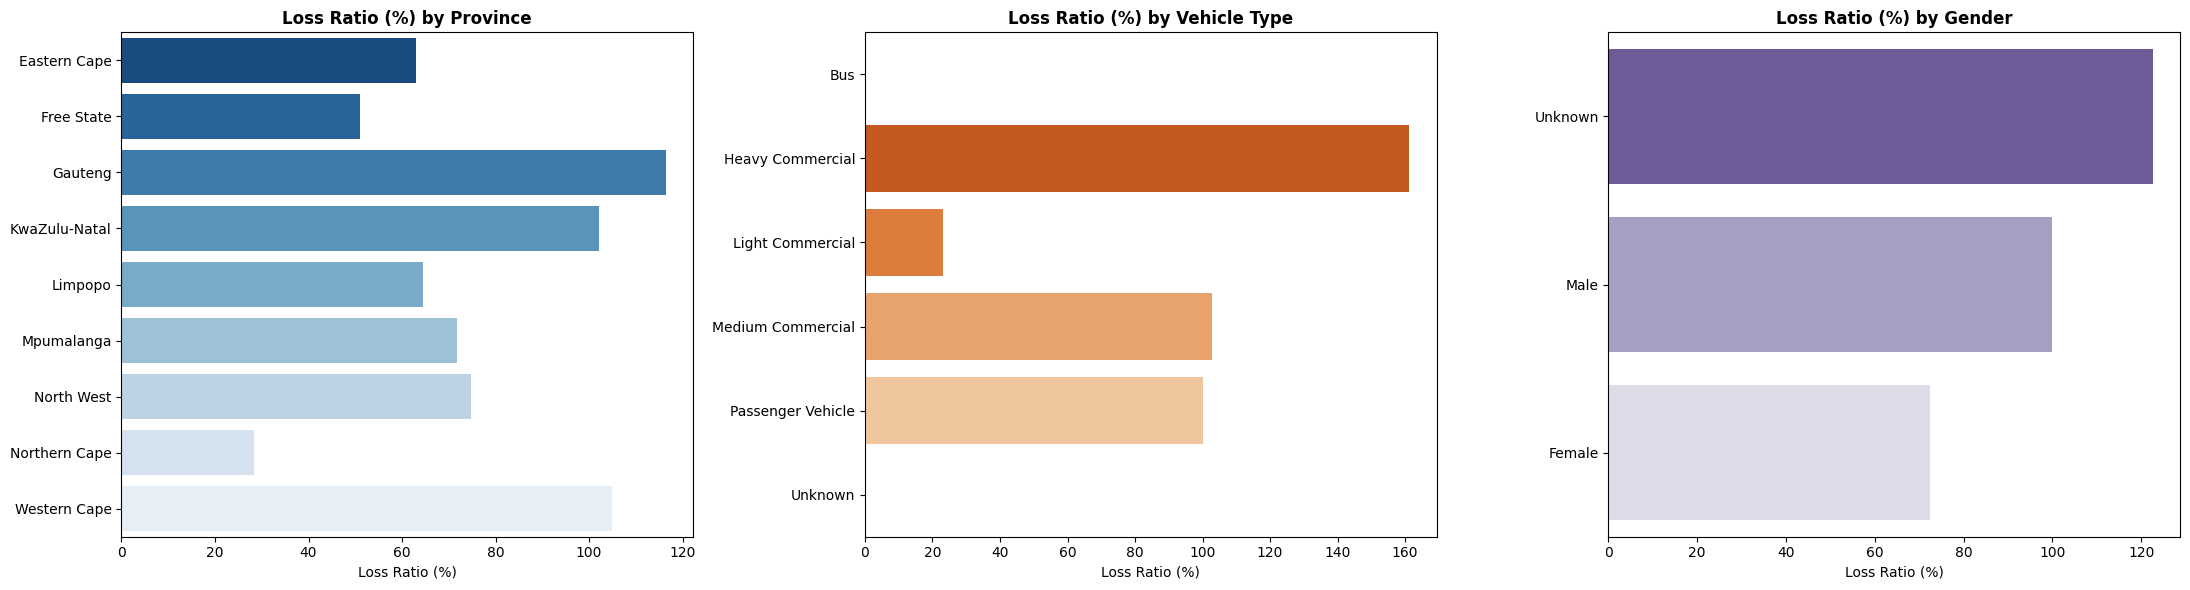

In [14]:
plot_loss_ratio(df_clean)


he portfolio has critical profitability leaks across several dimensions.

Geography: Gauteng is operating at a severe loss with a Loss Ratio exceeding 110% (the company pays out more in claims than it collects). Western Cape and KwaZulu-Natal are also hovering at the unprofitability line (~100%).

Vehicle Type: Heavy Commercial vehicles are a massive financial drain, soaring past a 160% Loss Ratio. Light Commercial vehicles, conversely, are highly profitable.

Gender: Policies where gender is "Not specified" are the worst performers (>100% Loss Ratio).

Business Recommendation: Immediately initiate a rate review to increase premiums for Heavy Commercial policies and policies located in Gauteng. Additionally, audit the "Not specified" gender segment—if these are commercial fleets, they must be moved to a stricter, fleet-specific pricing matrix.

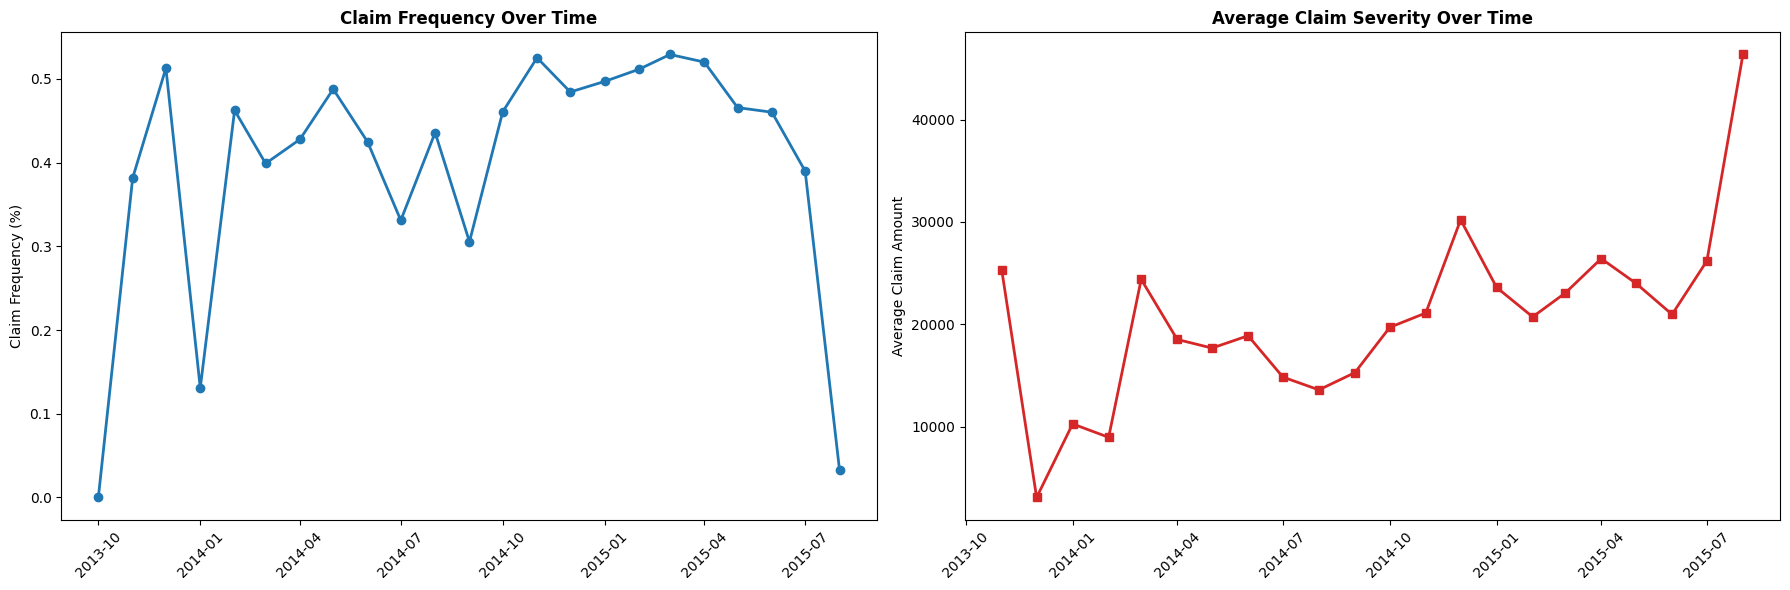

In [15]:
plot_temporal_trends(df_clean)


Claim frequency remained largely stable between 0.3% and 0.5% over the 18 months. However, claim severity (the average cost of a claim) experienced an unprecedented spike at the very end of the period, nearly doubling in July 2015.

Business Recommendation: A sudden severity spike without a corresponding frequency spike typically points to high-impact external events (e.g., localized severe weather destroying high-value assets, or a cluster of severe commercial accidents). The analytics team must drill down specifically into the claims filed in July 2015 to identify the root cause and adjust future predictive risk models to account for this tail risk.

c:\Users\Hermela\Desktop\10academy\week3\src\visualizations.py:217: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index.astype(str), palette='Reds_r', ax=axes[0])
c:\Users\Hermela\Desktop\10academy\week3\src\visualizations.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_10.values, y=bottom_10.index.astype(str), palette='Greens_r', ax=axes[1])


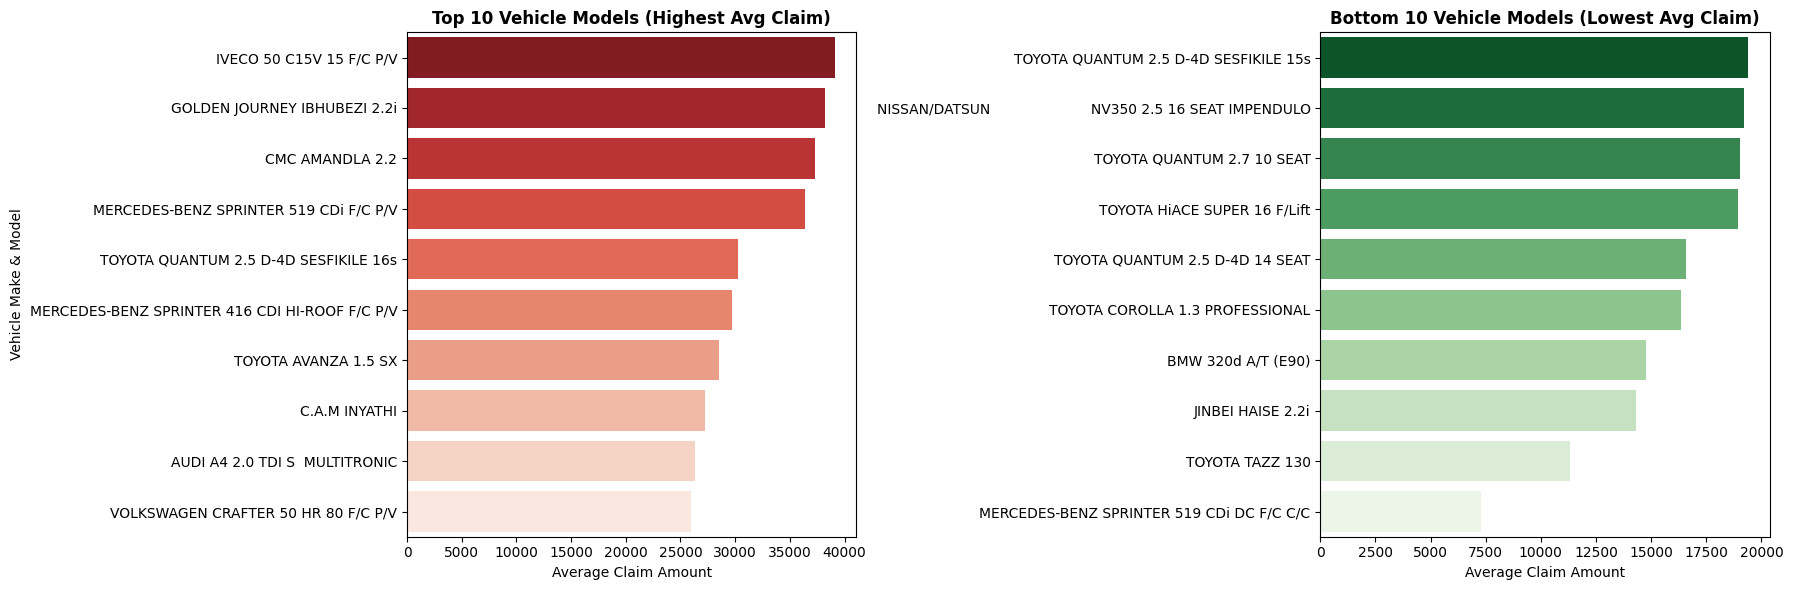

In [16]:
plot_vehicle_claims(df_clean)

Specialty and heavy commercial brands are driving the highest payouts. Specific models from IVECO and CMC top the list, generating massive average claims. Conversely, standard consumer models from Nissan, Toyota, and BMW generate the lowest average claims.

Business Recommendation: Commercial trucks cause immense structural damage, driving up liability payouts. We must create a distinct, higher-tier pricing matrix specifically for heavy commercial models. Meanwhile, we should leverage the highly predictable risk of standard consumer vehicles to offer highly competitive pricing, as retaining these lower-risk customers is vital to keeping the portfolio afloat.